### Importing Libraries


In [1]:
# Importing the python libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')


#### Load Data

In [2]:
# Load the Dataset.
customer_transaction_data = pd.read_csv(r"C:/Users/HP/Downloads/Fraudulent_Transaction_Detection_For_Finlora_Company/Finlora_Dataset/FinLora_Customer_Transaction_Dataset.csv")
customer_transaction_data.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
customer_transaction_data.tail()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,...,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [4]:
customer_transaction_data.sample()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
1640,5f0fb721-8bb5-4318-910a-1297db741276,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-04-03 08:11:59.468549+00:00,UK,GBP,NGN,mobile,160.03,200.04,3.71,...,0.213,standard,4,0.892,0,0.407,0,0,0.22,0


#### Data Overview

In [5]:
# Checking for number of rows and columns
customer_transaction_data.shape

(11400, 26)

In [6]:
# Checking for all the columns in the dataset
customer_transaction_data.columns


Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='object')

In [7]:
customer_transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

In [8]:
customer_transaction_data['amount_src'].value_counts(dropna=False).head(20)

amount_src
100       15
102.29     5
71.78      4
115.29     4
261.23     4
119.15     4
102.37     4
105.2      4
250.19     4
94.34      4
54.74      4
167.16     4
58.93      4
121.3      4
82.25      4
128.93     4
144.29     4
37.56      3
103.24     3
59.54      3
Name: count, dtype: int64

In [9]:
# Classify Variable


identifier_variables = [
    'transaction_id',
    'customer_id',
    'device_id',
    'ip_address'
]

target_variable = [
    'is_fraud'
]

datetime_variables = [
    'timestamp'
]

categorical_variables = [
    'home_country',
    'source_currency',
    'dest_currency',
    'channel',
    'ip_country',
    'kyc_tier'
]

numerical_variables = [
    'amount_usd',
    'fee',
    'exchange_rate_src_to_dest',
    'ip_risk_score',
    'account_age_days',
    'device_trust_score',
    'chargeback_history_count',
    'risk_score_internal',
    'txn_velocity_1h',
    'txn_velocity_24h',
    'corridor_risk'
]

boolean_variables = [
    'new_device',
    'location_mismatch'
]

print("Identifier variables:")
print(identifier_variables)

print("\nTarget variable:")
print(target_variable)

print("\nDatetime variables:")
print(datetime_variables)

print("\nCategorical variables:")
print(categorical_variables)

print("\nNumerical variables:")
print(numerical_variables)

print("\nBoolean variables:")
print(boolean_variables)

Identifier variables:
['transaction_id', 'customer_id', 'device_id', 'ip_address']

Target variable:
['is_fraud']

Datetime variables:
['timestamp']

Categorical variables:
['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier']

Numerical variables:
['amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk']

Boolean variables:
['new_device', 'location_mismatch']


In [10]:
# Identify Primary, Foreign Keys & Duplicate


print("Checking transaction_id uniqueness...")

transaction_id_duplicates = (
    customer_transaction_data['transaction_id']
    .duplicated()
    .sum()
)

print("Duplicate transaction IDs:",
      transaction_id_duplicates)

print(
    "Unique transaction IDs:",
    customer_transaction_data['transaction_id'].nunique()
)

print(
    "Total records:",
    len(customer_transaction_data)
)

Checking transaction_id uniqueness...
Duplicate transaction IDs: 200
Unique transaction IDs: 11200
Total records: 11400


In [11]:
duplicate_rows = customer_transaction_data.duplicated()

print("\nNumber of exact duplicate rows:",
      duplicate_rows.sum())

print("Percentage of exact duplicate rows:",
      round((duplicate_rows.sum() /
             len(customer_transaction_data)) * 100, 2), "%")


Number of exact duplicate rows: 200
Percentage of exact duplicate rows: 1.75 %


In [12]:
# Remove Duplicates
customer_transaction_data_clean = (
    customer_transaction_data.drop_duplicates()
)


In [13]:
print("\nDataset shape before removing duplicates:",
      customer_transaction_data.shape)

print("Dataset shape after removing duplicates:",
      customer_transaction_data_clean.shape)

print("Number of rows removed:",
      len(customer_transaction_data) -
      len(customer_transaction_data_clean))



Dataset shape before removing duplicates: (11400, 26)
Dataset shape after removing duplicates: (11200, 26)
Number of rows removed: 200


In [14]:
# Number of unique customers
print(
    "Unique customers:",
    customer_transaction_data['customer_id'].nunique()
)

# Number of transactions per customer
transactions_per_customer = (
    customer_transaction_data
    .groupby('customer_id')
    .size()
    .sort_values(ascending=False)
)

display(transactions_per_customer.head(10))

Unique customers: 1315


customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
7bd5200c-5d19-44f0-9afe-8b339a05366b     811
70a93d26-8e3a-4179-900c-a4a7a74d08e5     677
f7531a78-8bbe-4a85-b1e8-a0650edddc72     394
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     360
23d9943d-57b1-42eb-9ef2-05eed7fd1957     347
dtype: int64

##### Observations:
##### Transaction_id is the strongest candidate for the primary key
##### customer_id → customer identifier / logical foreign key
##### device_id → device identifier
##### ip_address → network identifier

Because there is no separate customer table in this CSV, customer_id functions as a relational key within the integrated dataset rather than an enforced database foreign key.

In [15]:
# Checking for missing values
customer_transaction_data.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [16]:
# Checking Info/Data type

customer_transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

##### SUMMARY / OBSERVATIONS

##### The dataset contains 11,400 records and 26 variables, providing a substantial volume of transaction-level information for fraud detection analysis.
##### The field names generally follow standard variable-naming conventions, which supports consistency and readability throughout the data analysis and modelling process.
##### An initial assessment of the dataset identified data-type inconsistencies in some variables. In particular, the timestamp field is currently stored as an object/string data type, rather than as a datetime variable. This should be converted to an appropriate datetime format to support accurate temporal analysis and enable the extraction of useful features such as transaction hour, day, month, and day of the week.
##### The amount_src variable is also currently stored as an object data type, although it represents a transaction amount and should ideally be converted to a numeric format such as float. This conversion is necessary to support mathematical calculations, statistical analysis, outlier detection, and machine-learning feature engineering.
#### The dataset contains 200 duplicates, which was handled.
##### The missing-value assessment identified incomplete records across several variables. Specifically:
##### timestamp contains 29 missing values.
##### amount_usd contains 305 missing values.
##### ip_address contains 305 missing values.
##### fee contains 295 missing values.
##### device_trust_score contains 295 missing values.
##### ip_country contains 301 missing values.
##### kyc_tier contains 300 missing values.
##### These missing observations will need to be investigated and appropriately handled during the data-cleaning and preprocessing stage. The treatment method will depend on the nature and importance of each variable and may include imputation, use of an "Unknown" category, or removal of records where appropriate.
##### The target variable, is_fraud, is highly imbalanced. Approximately 91% of transactions are classified as legitimate, while only 9% are identified as fraudulent. This represents a significant class imbalance that could cause machine-learning algorithms to favour the majority class and consequently miss fraudulent transactions.
##### Given the class imbalance, accuracy should not be used as the primary model evaluation metric. A model could achieve a high accuracy score simply by predicting most transactions as legitimate while performing poorly at identifying actual fraud. Instead, the project should place greater emphasis on precision, recall, F1-score, Precision-Recall AUC (PR-AUC), and the confusion matrix, with particular attention to fraud recall.
##### Appropriate class-imbalance techniques should be investigated during model development. These may include class weighting, SMOTE/resampling techniques, and classification-threshold optimization. The final approach should balance the business cost of missed fraudulent transactions against the operational cost of excessive false-positive alerts

In [17]:
# Checking for Label Inbalance

customer_transaction_data['is_fraud'].value_counts(normalize=True).reset_index()

,is_fraud,proportion
0,0,0.912544
1,1,0.087456


In [18]:
# Checking is_fraud Target Variable
print("is_fraud data type:")
print(customer_transaction_data['is_fraud'].dtype)

print("\nUnique is_fraud values:")
print(customer_transaction_data['is_fraud'].unique())

print("\nFrequency of is_fraud:")
print(
    customer_transaction_data['is_fraud']
    .value_counts(dropna=False)
)

is_fraud data type:
int64

Unique is_fraud values:
[0 1]

Frequency of is_fraud:
is_fraud
0    10403
1      997
Name: count, dtype: int64


In [19]:
# Calculate fraud rate
fraud_rate = customer_transaction_data['is_fraud'].mean() * 100

print(f"Fraud rate: {fraud_rate:.2f}%")

Fraud rate: 8.75%


In [20]:
# Potential Useful Fraud Variables

fraud_related_variables = [
    'amount_usd',
    'fee',
    'exchange_rate_src_to_dest',
    'new_device',
    'location_mismatch',
    'ip_risk_score',
    'kyc_tier',
    'account_age_days',
    'device_trust_score',
    'chargeback_history_count',
    'risk_score_internal',
    'txn_velocity_1h',
    'txn_velocity_24h',
    'corridor_risk',
    'channel',
    'home_country',
    'ip_country',
    'source_currency',
    'dest_currency',
    'timestamp'
]

print("Potentially useful fraud-related variables:")

for variable in fraud_related_variables:
    print("-", variable)

Potentially useful fraud-related variables:
- amount_usd
- fee
- exchange_rate_src_to_dest
- new_device
- location_mismatch
- ip_risk_score
- kyc_tier
- account_age_days
- device_trust_score
- chargeback_history_count
- risk_score_internal
- txn_velocity_1h
- txn_velocity_24h
- corridor_risk
- channel
- home_country
- ip_country
- source_currency
- dest_currency
- timestamp


##### Observation:
- is_fraud is clearly the binary target variable for the supervised machine-learning models.
- is_fraud must never be included as a predictor because it is the target. 
- Identifiers such as transaction ID, customer ID, device ID and raw IP address may also be excluded from the initial modelling feature set because they are identifiers rather than behavioural measurements and can introduce high cardinality, memorisation, leakage or privacy concerns.

##### Data Cleaning And Preparation


In [21]:
#converting data types of timestamp to datetime
customer_transaction_data['timestamp'] = pd.to_datetime(customer_transaction_data['timestamp'],errors='coerce') 
#converting data type of income_usd to float 
customer_transaction_data['amount_src'] = pd.to_numeric(customer_transaction_data['amount_src'],errors='coerce')

In [22]:
# Checking the data again to confirm the data type
customer_transaction_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11396 non-null  float64            
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

In [23]:
# Rechecking for missing data
customer_transaction_data.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

##### Data Type Conversion and Validation

##### During the data preprocessing stage, the timestamp and amount_src variables were converted from their original object/string formats into appropriate data types. The timestamp variable was converted to a datetime format using pd.to_datetime(), while amount_src was converted to a numeric format using pd.to_numeric(). Both conversions used the errors="coerce" argument to ensure that invalid or incorrectly formatted values were converted to missing values(resulting an increase in missing values) rather than causing the preprocessing process to fail.

##### Following the conversion, additional invalid records were identified. The number of missing values in timestamp increased from 29 to 61, indicating that 32 additional timestamp entries contained values that could not be correctly interpreted as dates or timestamps.

##### Similarly, amount_src initially contained no missing values; however, after conversion, 4 values were identified as invalid and converted to missing values. This suggests that these records contained improperly formatted, non-numeric, or corrupted transaction amounts.

##### These findings highlight the importance of data-type validation during preprocessing. The newly identified missing values were subsequently included in the data-cleaning process, where appropriate treatment methods were applied to maintain data quality and minimize the potential impact on subsequent exploratory analysis and machine-learning modelling.


##### VARIABLES WITH MISSING VALUES THAT NEEDS IMPUTATION
##### During the data-cleaning stage, the variables containing missing values were reviewed and appropriate treatment methods were selected based on the nature and business meaning of each variable

#####  amount usd: has 305 missing values. this will be filled by multiplying the amount_ src by the exchange rate of the currency. 
##### fee: has 295 missing values which will be filled by the median of channel variable if channel exists while other remaining fee missing values wil be filled using the overall median.
##### ip country: has 301 missing values which will be filled by the corresponding home_country 
##### kyc tier: has 300 missing values which will be filled with the most frequent kyc_tier(mode).
##### device trust score: has 295 missing values. This will be filled by the median of the group from grouping device_trust score by kyc_tier and new_ device variable or by the overal median of device.trust_score.
##### The timestamp variable which has 61 missing values and amount_src with 4 missing values will be dropped uSing the dropna method because the number of missing values in both variables is very small compared to the values we have on our dataset_ The ip_address variable has missing values of 305 cannot be filled with any value as each ip_address is a unique number so it will be dropped using the dropna method

In [24]:

#calculating exchange rates per currency .
exchange_rates = customer_transaction_data[customer_transaction_data['amount_usd'].notna()].groupby('source_currency').apply(
    
    lambda x: (x['amount_usd'] / x['amount_src']).mean() 
    ).to_dict() 
exchange_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.223441221648679,
 'USD': 0.9838730321259439}

In [25]:
# Filling the missing values of the amount_usd 
customer_transaction_data['amount_usd']=customer_transaction_data.apply(
    lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'],1),
    axis=1
)


In [26]:
# Filling the missing values of the fee variables
if 'fee' in customer_transaction_data.columns:
   if 'channel' in customer_transaction_data.columns:
      customer_transaction_data['fee'] = customer_transaction_data.groupby('channel')['fee'].transform(lambda y: y.fillna(y.median()))
   customer_transaction_data['fee'] = customer_transaction_data['fee'].fillna(customer_transaction_data['fee'].median())

In [27]:
# Filling the missing values of ip_country variables
if {'ip_country', 'home_country'}.issubset(customer_transaction_data.columns):
    customer_transaction_data['ip_country'] = customer_transaction_data['ip_country'].fillna(customer_transaction_data['home_country'])

In [28]:
# Filling the missing values of device_trust_score variable
if 'device_trust_score' in customer_transaction_data.columns:
    if{'new_device', 'kyc_tier'}.issubset(customer_transaction_data.columns):
        customer_transaction_data['device_trust_score']*customer_transaction_data.groupby(['new_device', 'kyc_tier'])['device_trust_score'].transform(lambda x: x.fillna(x.median()))
        customer_transaction_data['device_trust_score']*customer_transaction_data['device_trust_score'].fillna(customer_transaction_data['device_trust_score'].median())


In [29]:
# Dropping the timestamp, amount_src and ip_address missing values
customer_transaction_data.dropna(subset=['timestamp', 'amount_src', 'ip_address'], inplace=True)

In [30]:
# Recheck for missing values
customer_transaction_data.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64

#### Steps for performing a data sanity check:
##### * ​Check for invalid numbers: Identify negative values in variables that should strictly be non-negative, such as age, monetary amounts, or transaction velocity.
##### * ​Check future timestamps: Ensure transaction timestamps do not contain dates or times set in the future relative to the dataset boundary or current time.
##### ​* Verify expected ranges: Confirm that numeric and categorical values fall within plausible, predefined logical ranges (e.g., percentages between 0–100, valid risk scores).
##### ​* Inspect variable consistency in the dataset: Cross-check related fields for logical conflicts (e.g., a transaction marked complete without a corresponding completed timestamp or valid account ID).

In [31]:
# Checking negative values in the numerical columns
negative_counts = {
    'amount_src': (customer_transaction_data['amount_src'] < 0).sum(),
    'amount_usd': (customer_transaction_data['amount_usd'] < 0).sum(),
    'fee': (customer_transaction_data['fee'] < 0).sum(),
    'device_trust_score': (customer_transaction_data['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (customer_transaction_data['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (customer_transaction_data['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (customer_transaction_data['risk_score_internal'] < 0).sum()    
}
negative_counts

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(90),
 'device_trust_score': np.int64(190),
 'txn_velocity_1h': np.int64(190),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [32]:
# Drop the negative(less than < 0) variables
customer_transaction_data = customer_transaction_data.drop(customer_transaction_data[
    (customer_transaction_data['amount_src'] < 0) |
    (customer_transaction_data['fee'] < 0) |
    (customer_transaction_data['device_trust_score'] < 0) |
(customer_transaction_data['txn_velocity_1h'] < 0)] .index)

In [33]:
# Rechecking for negtive numbers
negative_counts = {
    'amount_src': (customer_transaction_data['amount_src'] < 0).sum(),
    'amount_usd': (customer_transaction_data['amount_usd'] < 0).sum(),
    'fee': (customer_transaction_data['fee'] < 0).sum(),
    'device_trust_score': (customer_transaction_data['device_trust_score'] < 0).sum(),
    'txn_velocity_1h': (customer_transaction_data['txn_velocity_1h'] < 0).sum(),
    'txn_velocity_24h': (customer_transaction_data['txn_velocity_24h'] < 0).sum(),
    'risk_score_internal': (customer_transaction_data['risk_score_internal'] < 0).sum()    
}
negative_counts

{'amount_src': np.int64(0),
 'amount_usd': np.int64(0),
 'fee': np.int64(0),
 'device_trust_score': np.int64(0),
 'txn_velocity_1h': np.int64(0),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [34]:
# Checking for futuristic timestamp
customer_transaction_data[customer_transaction_data['timestamp'] >pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [35]:
# Checking for location mismatch
customer_transaction_data['location_mismatch'].value_counts().reset_index()

,location_mismatch,count
0,False,9047
1,True,1793


In [36]:
# Reviewing the channel variable
customer_transaction_data['channel'].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
       'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

In [37]:
# Formating the channel variable
customer_transaction_data['channel'] = customer_transaction_data['channel'].str.lower().str.strip()
customer_transaction_data['channel'].unique()

array(['atm', 'web', 'mobile', 'unknown', 'mobille', 'weeb'], dtype=object)

In [38]:
customer_transaction_data['channel'] = customer_transaction_data['channel'].replace({
    'weeb':'web',
    'mobille':'mobile',
})


In [39]:
import numpy as np
customer_transaction_data['channel'] = customer_transaction_data['channel'].replace({'unknown':np.nan})
customer_transaction_data['channel'].unique()

array(['atm', 'web', 'mobile', nan], dtype=object)

In [40]:
# Reviewing the source currency variable
customer_transaction_data['source_currency'].unique()

array(['USD', 'CAD', 'GBP'], dtype=object)

In [41]:
# Reviewing the destination currency
customer_transaction_data['dest_currency'].unique()

array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
      dtype=object)

In [42]:
# Reviewing for kyc tier variabler
customer_transaction_data['kyc_tier'].unique() 

array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
       ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW'], dtype=object)

In [43]:
# Formating the kyc variable
customer_transaction_data['kyc_tier'] = customer_transaction_data['kyc_tier'].str.lower().str.strip()
customer_transaction_data['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', 'standrd', 'unknown', 'enhancd'],
      dtype=object)

In [44]:
import numpy as np
customer_transaction_data['kyc_tier'] = customer_transaction_data['kyc_tier'].replace({
    'standrd':'standard',
    'enhancd':'enhanced',
    'unknown': np.nan
})
customer_transaction_data['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', nan], dtype=object)

In [45]:
customer_transaction_data.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                      36
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                     29
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
dtype: int64

In [46]:
customer_transaction_data.dropna(inplace=True)
customer_transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10780 non-null  object             
 1   customer_id                10780 non-null  object             
 2   timestamp                  10780 non-null  datetime64[ns, UTC]
 3   home_country               10780 non-null  object             
 4   source_currency            10780 non-null  object             
 5   dest_currency              10780 non-null  object             
 6   channel                    10780 non-null  object             
 7   amount_src                 10780 non-null  float64            
 8   amount_usd                 10780 non-null  float64            
 9   fee                        10780 non-null  float64            
 10  exchange_rate_src_to_dest  10780 non-null  float64            
 11  device_

In [47]:
customer_transaction_data.isnull().sum()

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64

In [48]:
# Reviewing the home country variable
customer_transaction_data['home_country'].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

In [49]:
# Formating the home country variable
customer_transaction_data['home_country'] = customer_transaction_data['home_country'].str.lower().str.strip()
customer_transaction_data['home_country'].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

In [50]:
customer_transaction_data['home_country'] = customer_transaction_data['home_country'].replace({
        'unknown': np.nan
})
customer_transaction_data['home_country'].unique()

array(['us', 'ca', 'uk', nan], dtype=object)

In [51]:
# Reviewing the ip country variable
customer_transaction_data['ip_country'].unique()

array(['US', 'CA', 'UK', ' US  ', 'unknown', ' CA  ', ' UK  '],
      dtype=object)

In [52]:
#  Formating the ip country variable
customer_transaction_data['ip_country'] = customer_transaction_data['ip_country'].str.lower().str.strip()
customer_transaction_data['ip_country'].unique()


array(['us', 'ca', 'uk', 'unknown'], dtype=object)

In [53]:
customer_transaction_data['ip_country'] = customer_transaction_data['ip_country'].replace({
    'unknown': np.nan
})
customer_transaction_data['ip_country'].unique()

array(['us', 'ca', 'uk', nan], dtype=object)

In [54]:
customer_transaction_data.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


##### FinLora Dataset Dictionary

| S/N | Column Name                 | Data Type   | Description                                                                                                     | Example               |
| --: | --------------------------- | ----------- | --------------------------------------------------------------------------------------------------------------- | --------------------- |
|   1 | `transaction_id`            | String      | Unique identifier assigned to each financial transaction.                                                       | `TXN10045892`         |
|   2 | `customer_id`               | String      | Unique identifier for the customer initiating or associated with the transaction.                               | `CUS002341`           |
|   3 | `timestamp`                 | Datetime    | Date and time when the transaction occurred.                                                                    | `2026-07-15 14:35:22` |
|   4 | `home_country`              | String      | Country where the customer account is registered.                                                               | `UK`                  |
|   5 | `source_currency`           | String      | Currency used by the sender.                                                                                    | `GBP`                 |
|   6 | `dest_currency`             | String      | Currency received by the recipient.                                                                             | `USD`                 |
|   7 | `channel`                   | Categorical | Digital channel through which the transaction was initiated.                                                    | `Mobile App`          |
|   8 | `amount_src`                | Float       | Transaction amount in the source currency.                                                                      | `500.00`              |
|   9 | `amount_usd`                | Float       | Transaction amount converted to USD.                                                                            | `620.50`              |
|  10 | `fee`                       | Float       | Transaction fee charged by the platform.                                                                        | `5.50`                |
|  11 | `exchange_rate_src_to_dest` | Float       | Exchange rate applied from the source currency to the destination currency.                                     | `1.24`                |
|  12 | `device_id`                 | String      | Unique identifier for the device used to initiate the transaction.                                              | `DEV98765`            |
|  13 | `new_device`                | Binary      | Indicates whether the device is new. `1 = Yes`, `0 = No`.                                                       | `1`                   |
|  14 | `ip_address`                | String      | IP address used for the transaction.                                                                            | `192.168.0.1`         |
|  15 | `ip_country`                | String      | Country detected from the transaction IP address.                                                               | `Germany`             |
|  16 | `location_mismatch`         | Binary      | Indicates whether the IP country differs from the customer's home country. `1 = Yes`, `0 = No`.                 | `1`                   |
|  17 | `ip_risk_score`             | Float       | Risk score assigned to the IP address.                                                                          | `0.72`                |
|  18 | `kyc_tier`                  | Integer     | Customer KYC verification level.                                                                                | `2`                   |
|  19 | `account_age_days`          | Integer     | Number of days since the customer's account was created.                                                        | `365`                 |
|  20 | `device_trust_score`        | Float       | Trust score assigned to the device used for the transaction.                                                    | `0.85`                |
|  21 | `chargeback_history_count`  | Integer     | Number of previous chargebacks associated with the customer or account.                                         | `1`                   |
|  22 | `risk_score_internal`       | Float       | Internal fraud-risk score assigned to the transaction or customer.                                              | `0.67`                |
|  23 | `txn_velocity_1h`           | Integer     | Number of transactions completed within the previous one-hour period.                                           | `3`                   |
|  24 | `txn_velocity_24h`          | Integer     | Number of transactions completed within the previous 24-hour period.                                            | `12`                  |
|  25 | `corridor_risk`             | Float       | Risk score associated with the transaction's country or currency corridor.                                      | `0.55`                |
|  26 | `is_fraud`                  | Binary      | Target variable indicating whether the transaction was identified as fraudulent. `1 = Fraud`, `0 = Legitimate`. | `0`                   |


In [55]:
# Identify Join Keys

print("Transaction ID:")
print(customer_transaction_data['transaction_id'].head())

print("\nCustomer ID:")
print(customer_transaction_data['customer_id'].head())

print("\nFraud target:")
print(customer_transaction_data['is_fraud'].head())

Transaction ID:
0    fee8542d-8ee6-4b0d-9671-c294dd08ed26
1    bfdb9fc1-27fe-4a85-b043-4d813d679259
2    fc855034-3ea5-4993-9afa-b511d93fe5e8
3    2cf8c08e-42ec-444d-a755-34b9a2a0a4ca
4    d907a74d-b426-438d-97eb-dbe911aca91c
Name: transaction_id, dtype: object

Customer ID:
0    402cccc9-28de-45b3-9af7-cc5302aa1f93
1    67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad
2    6d0d9b27-fa26-45f8-93b1-2df29d182d9c
3    7bd5200c-5d19-44f0-9afe-8b339a05366b
4    70a93d26-8e3a-4179-900c-a4a7a74d08e5
Name: customer_id, dtype: object

Fraud target:
0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64


##### Observation:
##### The attached CSV is already an integrated transaction-level dataset. It does not contain three separate physical files/tables for customers, transactions, and fraud investigations. The customer, transaction, device/IP, risk, and fraud-label information are already represented as columns in the same table.

##### Therefore, I recommend that my notebook documents the logical integration and validates the relationships, rather than artificially joining the same table to itself.



In [56]:
# Validate Customer-Transaction One-To-Many Relationship


customer_transaction_counts = (
    customer_transaction_data
    .groupby('customer_id')
    .size()
    .reset_index(name='transaction_count')
)

print("Number of unique customers:",
      customer_transaction_counts.shape[0])

print("\nCustomers with the most transactions:")
display(
    customer_transaction_counts
    .sort_values('transaction_count', ascending=False)
    .head(10)
)

Number of unique customers: 1313

Customers with the most transactions:


,customer_id,transaction_count
327,402cccc9-28de-45b3-9af7-cc5302aa1f93,1429
1119,d71c91b4-fee8-4104-9856-a5c6109a62e3,1268
599,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,1230
580,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,995
919,af8ca4c4-8703-4c55-b66c-2b76cd70040d,860
666,7bd5200c-5d19-44f0-9afe-8b339a05366b,769
604,70a93d26-8e3a-4179-900c-a4a7a74d08e5,647
1261,f7531a78-8bbe-4a85-b1e8-a0650edddc72,371
559,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,340
183,23d9943d-57b1-42eb-9ef2-05eed7fd1957,328


##### Observation:
##### This confirms that multiple transaction records can legitimately belong to the same customer.

In [57]:
# Verify Fraud Label Relationship

fraud_label_per_transaction = (
    customer_transaction_data
    .groupby('transaction_id')['is_fraud']
    .nunique(dropna=False)
)

transactions_with_multiple_fraud_labels = (
    (fraud_label_per_transaction > 1).sum()
)

print(
    "Transactions with conflicting fraud labels:",
    transactions_with_multiple_fraud_labels
)

Transactions with conflicting fraud labels: 0


In [58]:
# Verify Fraud Labels

print("Fraud label values:")
print(
    customer_transaction_data['is_fraud']
    .unique()
)

print("\nFraud label distribution:")
print(
    customer_transaction_data['is_fraud']
    .value_counts(dropna=False)
)

Fraud label values:
[0 1]

Fraud label distribution:
is_fraud
0    9799
1     981
Name: count, dtype: int64


In [59]:
# Verify Class Distribution After Cleaning

fraud_distribution = (
    customer_transaction_data["is_fraud"]
    .value_counts()
    .sort_index()
)

fraud_percentage = (
    customer_transaction_data["is_fraud"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("\nFraud class distribution:")
print(fraud_distribution)

print("\nFraud class percentage:")
print(fraud_percentage.round(2))




Fraud class distribution:
is_fraud
0    9799
1     981
Name: count, dtype: int64

Fraud class percentage:
is_fraud
0    90.9
1     9.1
Name: proportion, dtype: float64


##### Data Cleaning Decisions and Validation Results

##### The FinLora transaction dataset was cleaned to improve data consistency, reliability, and suitability for fraud detection modelling.

The following cleaning decisions were applied:

1. Missing numeric values in `amount_usd`, `fee`, and `device_trust_score`
   were handled using median imputation, with missing-value indicator
   variables retained to preserve information about the original missingness.

2. Missing categorical values in `home_country`, `ip_country`, `kyc_tier`,
   and `ip_address` were represented as `unknown`.

3. Invalid and missing timestamp values were converted to datetime.
   Records without a valid timestamp were removed because timestamp
   information is required for temporal and transaction-velocity analysis.

4. Duplicate transaction records were investigated using both complete-row
   duplication and `transaction_id` duplication. Exact duplicate records
   were removed.

5. `amount_src` was converted from text to numeric format after removing
   thousands separators.

6. Categorical variables were standardized by removing leading/trailing
   whitespace and applying consistent capitalization.

7. Known categorical errors were corrected, including:
   `standrd` → `standard`,
   `enhancd` → `enhanced`,
   `mobille` → `mobile`,
   `weeb` → `web`.

8. `ip_risk_score` values outside the expected 0–1 range and
   `device_trust_score` values outside the expected 0–1 range were treated
   as invalid and subsequently imputed.

9. Currency fields were standardized to uppercase.

10. Transaction IDs and customer IDs were validated to ensure that
    transactions could be associated with customers consistently.

11. The fraud target variable `is_fraud` was rechecked to ensure that it
    contained only valid binary values: 0 = legitimate and 1 = fraudulent.

12. The fraud class distribution was recalculated after cleaning to confirm
    the remaining level of class imbalance.

13. Identifier fields such as `transaction_id`, `customer_id`, and
    `device_id` were retained for traceability but should not be used
    directly as machine-learning predictor variables.



#### Exploratory Data Analysis

In [60]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette='Spectral'
)

#### Distribution of Fraud & Transaction Channels


##### The charts provide an initial understanding of the dataset and are important for the exploratory data analysis (EDA) stage. 

- The fraud distribution chart is used to examine the balance between fraudulent and legitimate transactions. This is particularly important for fraud detection because an imbalanced target variable can cause a machine learning model to favour the majority class and perform poorly when identifying fraudulent transactions. Understanding the level of class imbalance helps determine whether techniques such as class weighting, resampling, or appropriate evaluation metrics may be required.

- The transaction channel distribution chart shows how transactions are distributed across different channels, such as mobile, online, ATM, or other available channels. Examining this distribution helps identify dominant or underrepresented transaction channels and provides an initial indication of whether the channel may be relevant to fraudulent behavit ur. These observations can also guide subsequent feature analysis and model deve

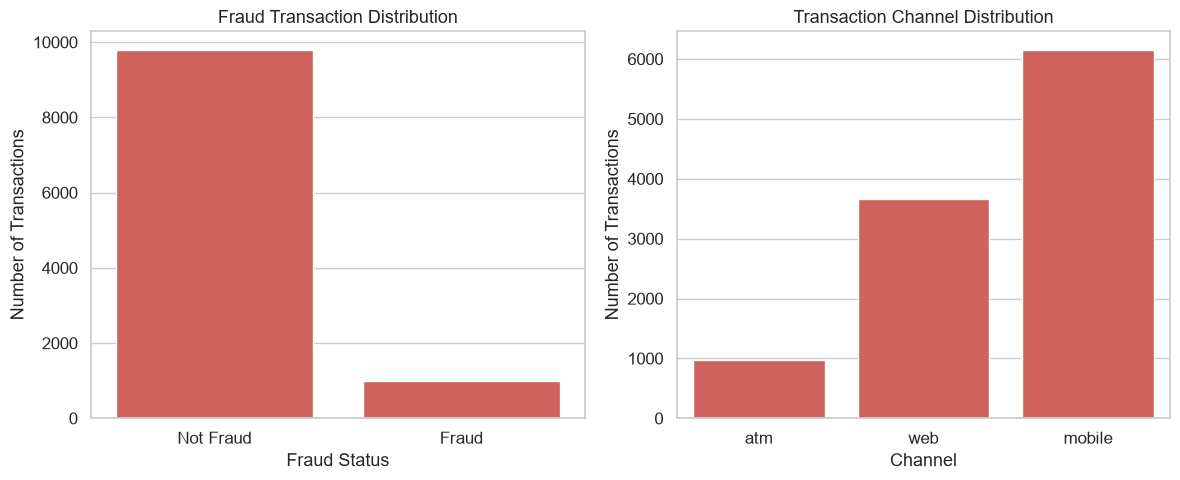

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fraud Distribution

sns.countplot(data=customer_transaction_data, x='is_fraud', ax=axes[0]) 
axes[0].set_title( 'Fraud Transaction Distribution')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0, 1]) 
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

# Channel distribution 

sns.countplot(data=customer_transaction_data, x='channel', ax=axes[1]) 
axes[1].set_title('Transaction Channel Distribution') 
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout() 
plt.show()

In [62]:
#  Fraud vs Legitimate Transaction Distribution

fraud_counts = (
    customer_transaction_data["is_fraud"]
    .value_counts()
    .sort_index()
)

fraud_labels = {
    0: "Legitimate",
    1: "Fraudulent"
}

fraud_distribution = fraud_counts.rename(index=fraud_labels)

print(fraud_distribution)

fraud_percentage = (
    customer_transaction_data["is_fraud"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index=fraud_labels)
)

print("\nPercentage distribution:")
print(fraud_percentage.round(2))

is_fraud
Legitimate    9799
Fraudulent     981
Name: count, dtype: int64

Percentage distribution:
is_fraud
Legitimate    90.9
Fraudulent     9.1
Name: proportion, dtype: float64


In [63]:
# Transaction Amount Analysis


amount_summary = (
    customer_transaction_data
    .groupby("is_fraud")["amount_usd"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
)

amount_summary.index = [
    "Legitimate",
    "Fraudulent"
]

print(amount_summary)

            count         mean  median  minimum   maximum
Legitimate   9799   394.949443  151.53     7.23  12497.90
Fraudulent    981  1036.256606  557.24    15.98  12496.24



##### IP Country and KYC Tier Analysis

The charts provide an overview of the distribution of transactions across IP countries and KYC tiers, while also examining their relationship with fraudulent transactions. The IP country distribution helps identify the countries from which transactions are predominantly initiated and highlights countries that may be underrepresented in the dataset. Similarly, the KYC tier distribution shows how transactions are distributed across different levels of customer verification, providing an understanding of the composition of the customer base.

The IP country versus fraud chart compares fraudulent and legitimate transactions across countries. This is useful for identifying whether fraudulent transactions are concentrated within particular geographic locations, which may indicate potential geographic patterns that could be relevant to fraud detection. However, differences in the total number of transactions across countries should be considered when interpleting the results.

The KYC tier versus fraud chart examines the distribution of fraudulent and legitimate transactions across different KYC verification levels. This analysis can help determine whether fraud occurrence varies across customer verification tiers and whether KYC status may provide useful predictive information for the fraud detection model.

Overall, these visualisations help identify potentia| patterns and relationships between customer verification, transaction origin, and fraudulent behaviour, which can inform subsequent feature engineering and machine learning model development

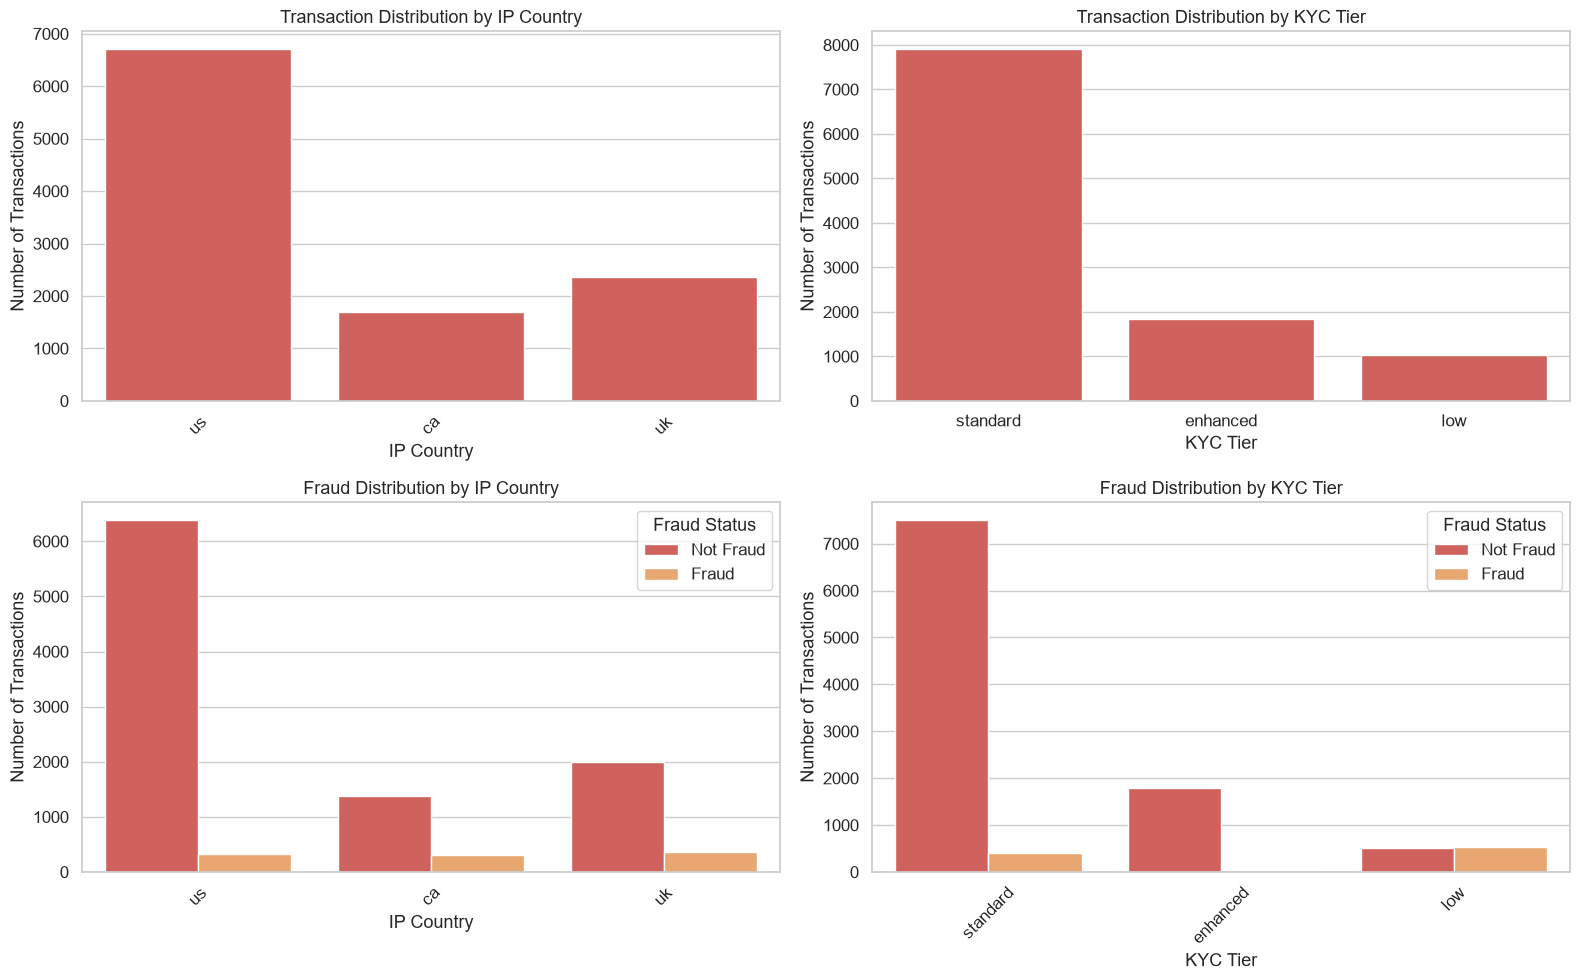

In [64]:
# Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. IP Country distribution

sns.countplot(
    data=customer_transaction_data, 
    x='ip_country', 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction Distribution by IP Country') 
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions') 
axes[0, 0].tick_params(axis='x', rotation=45)
                       
# 2. KYC Tier distributior 

sns.countplot( 
    data=customer_transaction_data, 
    x='kyc_tier',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction Distribution by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions') 

# IP Country vs Fraud

sns.countplot(
    data=customer_transaction_data,
    x='ip_country',
    hue='is_fraud',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Fraud Distribution by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transactions') 
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

# KYC Tier vs Fraud

sns.countplot(
    data=customer_transaction_data,
    x='kyc_tier',
    hue='is_fraud',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Distribution by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transactions') 
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()





#### Observation:

#### Fraud Rate Analysis by Location Mismatch, KYC Tier, and Transaction Channel

The visualizations show how fraudulent transaction behaviour varies across location mismatch. K¥C verification level, and transaction channel. The location mismatch analysis indicates a substantial difference in fraud risk depending on whether a transaction occurs in an expected location. Transactions where location mismatch = False, meaning the transaction location is consistent with the user's expected or previously observed location, have a relatively low fraud rate of approximately 3-5%. In contrast, transactions where location mismatch = True, indicating an unexpected or unfamiliar transaction location, have a considerably higher fraud rate of over 35%. Based the observed rates, transactions with a location mismatch are approximately 7-9 times more likely to be fraudulent than transactions without a location mismatch. This suggests that location mismatch may be an important predictive feature for identifying potentially fraudulent transactions.
Transaction Datas

The analysis of KYC tier also shows differences in fraud risk across customer verification levels. The results indicate customers with lower levels of KYC verification have higher fraud rates, while customers with enhanced verification have the lowest observed fraud risk. This suggests that the level of customer venfication may provide useful information for distinguishing between legitimate and potentially fraudulent transactions.

The transaction channel analysis provides two complementary perspectives. The fraud-rate chart measures the proportion of transactions that are fraudulent within each channel, while the fraud-count chart measures the actual number of fraudulent and non-fraudulent transactions, The results indicate that web transactions have a higher fraud rate than mobile transactions, suggesting that the web channel may present a relatively higher fraud risk However, fraud counts should be interpreted alongside fraud rates because differences in the total number of transactions across channels can influence the absolute number of fraudulent transactions.

Overall, these findings indicate that location mismatch, KYC verification level, and transaction channel may contain meaningful signals for fraud detection. These variables should therefore be considered during feature engineering and model development, while their predictive importance should ultimately be validated using statistical analysis and machine learning model evaluation.



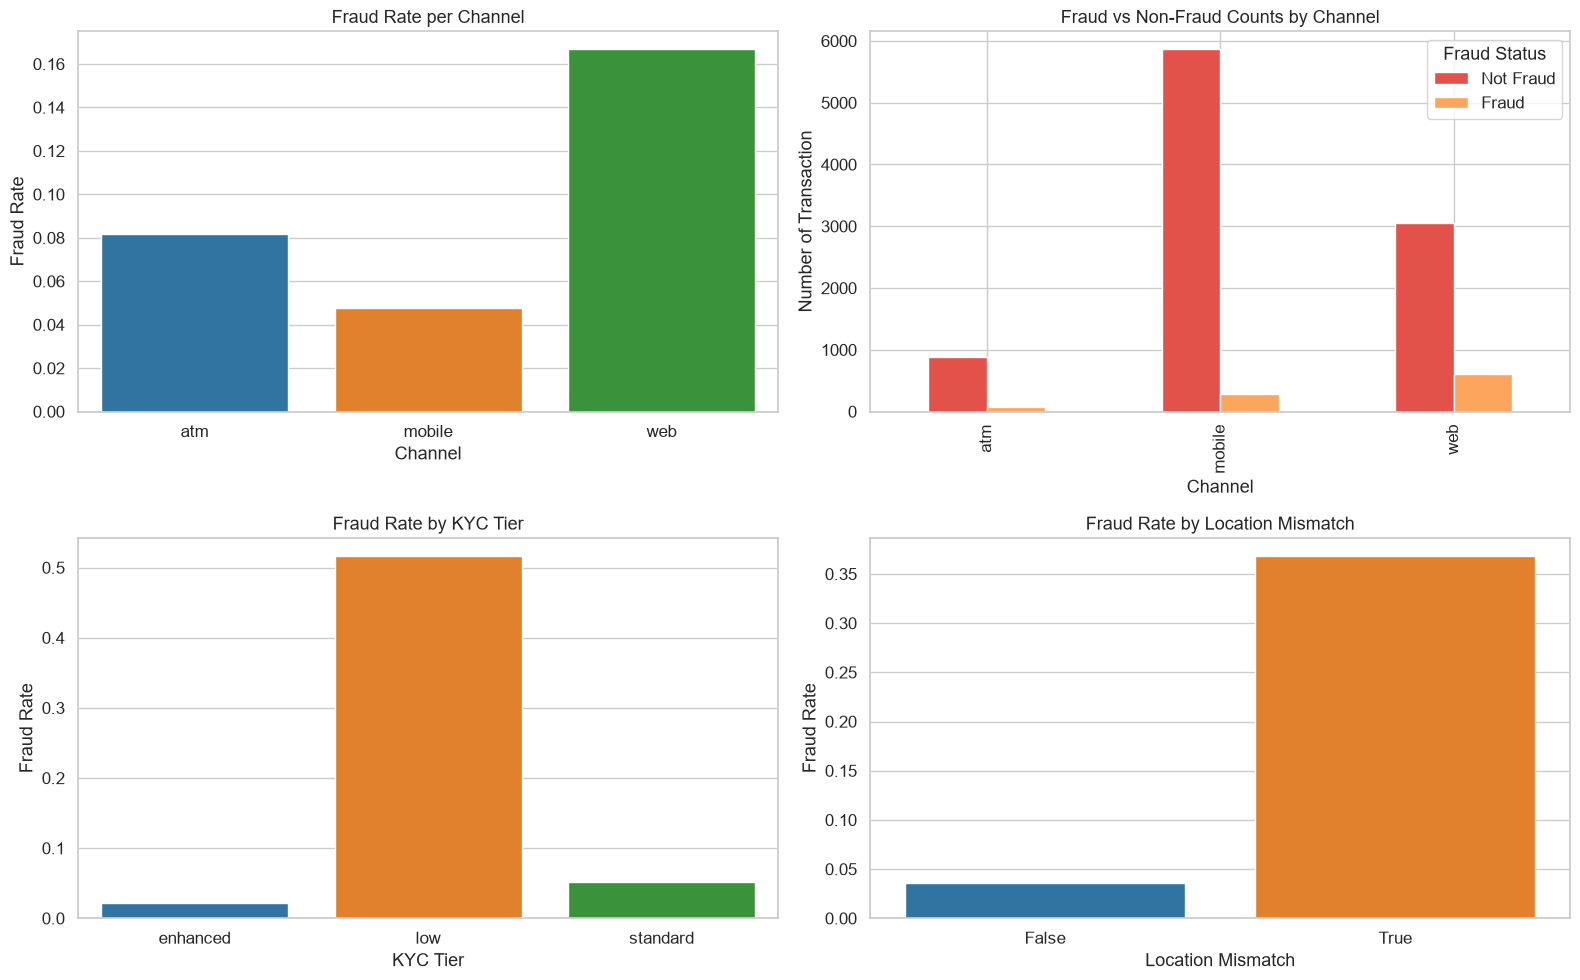

In [65]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud rate per channel

channel_fraud_rate = customer_transaction_data.groupby('channel')['is_fraud'].mean().reset_index()

sns.barplot(
data=channel_fraud_rate, 
x='channel', 
y='is_fraud', 
ax=axes[0, 0],
palette='tab10'
)

axes[0, 0].set_title('Fraud Rate per Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate')

# 2. Fraud vs Non-Fraud Counts per Channel

channel_counts = (
    customer_transaction_data.groupby('channel')["is_fraud"] 
    .value_counts()
    .unstack(fill_value=0) 
    .reset_index()
)

channel_counts = channel_counts.rename(
     columns={0: 'Not Fraud', 1: 'Fraud'}
)

channel_counts.plot(
     x='channel', 
     y=['Not Fraud', 'Fraud'], 
     kind='bar',
     ax=axes[0, 1]
)

axes[0, 1].set_title('Fraud vs Non-Fraud Counts by Channel')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transaction')
axes[0, 1].legend(title='Fraud Status')

# 3. Fraud Rate per KYC Tier

kyc_fraud_rate = customer_transaction_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud', 
    ax=axes[1, 0], 
    palette='tab10'
)

axes[1, 0].set_title('Fraud Rate by KYC Tier')
axes[1, 0].set_xlabel('KYC Tier') 
axes[1, 0].set_ylabel('Fraud Rate')

# 4. Fraud rate per location mismatch

location_fraud_rate = (
customer_transaction_data.groupby('location_mismatch')['is_fraud']
.mean () 
.reset_index()
)

sns.barplot( 
    data=location_fraud_rate, 
    x='location_mismatch', 
    y='is_fraud', 
    ax=axes[1, 1],
    palette='tab10'
)

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch') 
axes[1, 1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()






##### Transaction Velocity and Fraud Risk

The charts examine the relationship between transaction velocity and the likelihood of a transaction being fraudulent over both 1-hour and 24-hour periods. The results show a strong relationship between unusually higt transaction frequency and fraudulent activitv in the dataset.

For 1-hour transaction velocity, accounts making only one or two transactions within an hour have a very low fraud representing relatively normal transaction behaviour. However, a substantial increase occurs around the third where the fraud rate rises sharply to above 80%. The fraud rate remains particularly high between approximately 3 and 5 transactions per hour, reaching a bund 70-80%. This pattern suggests that rapid bursts of may be an important indicator of compromised accounts or automated fraudulent activity. Although begins to decline after five transactions and reaches approximately 45% around eight transactions per considerably higher than the baseline.

A similar pattern can be observed for 24-hour transaction velocity. Accounts making between 0 and 3 transactions have an extremely low observed fraud rate. However, the fraud rate increases substantially as transaction rises, reaching approximately 75% around five transactions per day. Between approximately 5 and 8 transactions, the fraud rate remains relatively high at around 70-80%, despite a slight decline around eight transactions. The rate then increases again, approaching 100% at around 10 transactions per day in the observed data.

Overall, the results suggest that transaction velocity is an important behavioural signal for fraud detection transaction frequency, particularly when transactions occur in rapid bursts, is strongly associated with fraudulent activitv in this dataset. These velocity-based features (txn velocity lh and txn velocity_ 24h) therefore provide valuable predictive information for the machine learning models. However, the observed rates should be interpreted as dataset-specific patterns rather than universal fraud thresholds, and their importance be validated during model training and evaluation.


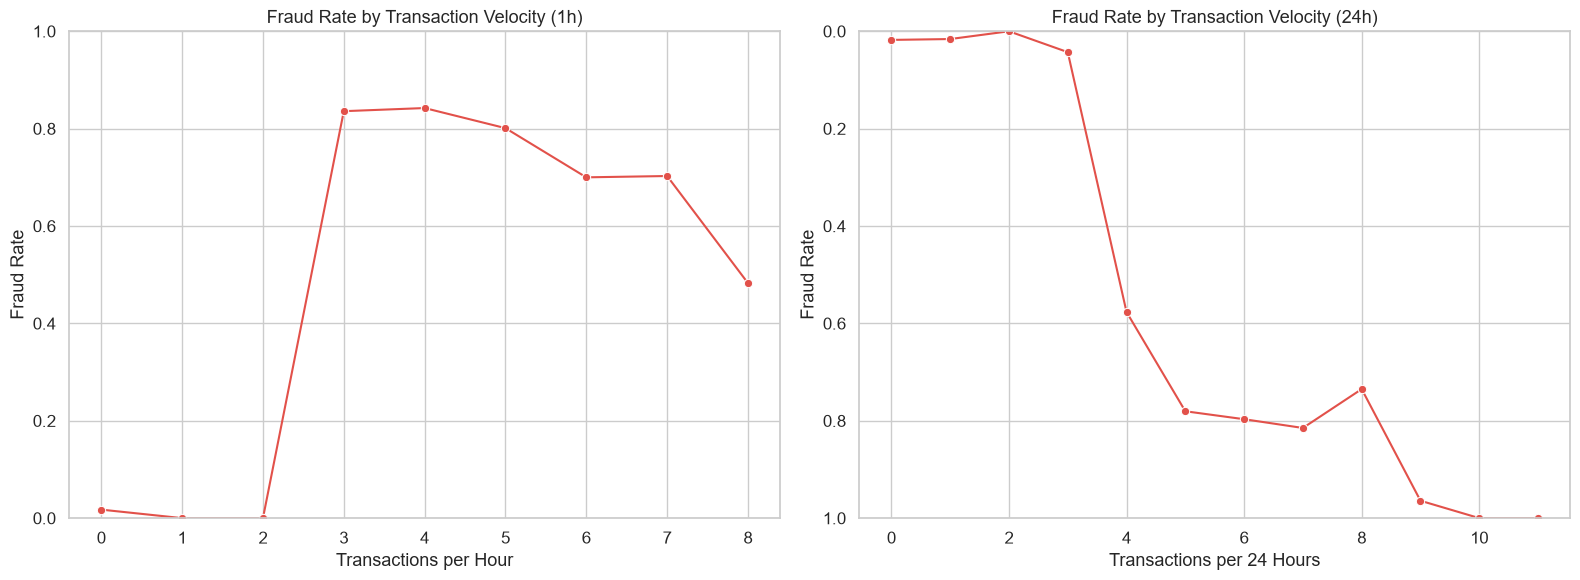

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Fraud rate by transaction velocity (1 hour)

txn_velocity_lh = (
    customer_transaction_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
   data=txn_velocity_lh,
   x='txn_velocity_1h', 
   y='is_fraud',
   marker='o', 
   ax=axes[0]
)

axes[0].set_title('Fraud Rate by Transaction Velocity (1h)') 
axes[0].set_xlabel('Transactions per Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)

# 2. Fraud Rate by Transaction Velocity (24 Hours)

txn_velocity_24h = (
    customer_transaction_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)

sns.lineplot(
   data=txn_velocity_24h,
   x='txn_velocity_24h', 
   y='is_fraud',
   marker='o', 
   ax=axes[1]
)

axes[1].set_title('Fraud Rate by Transaction Velocity (24h)') 
axes[1].set_xlabel('Transactions per 24 Hours')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(1, 0)

plt.tight_layout()
plt.show()



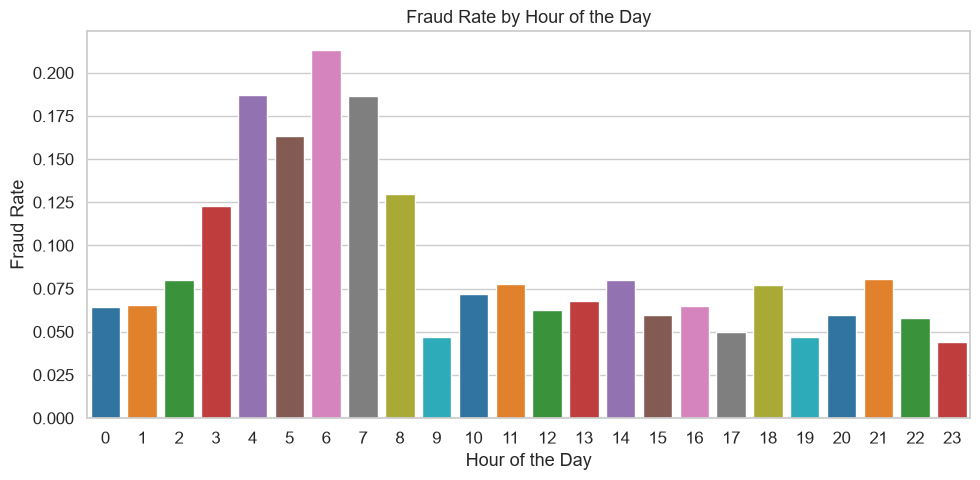

In [67]:
customer_transaction_data['timestamp'] = pd.to_datetime(customer_transaction_data['timestamp'])

# Extract time-based features 

customer_transaction_data['hour'] = customer_transaction_data['timestamp'].dt.hour 
customer_transaction_data['day_of_week'] = customer_transaction_data['timestamp'].dt.dayofweek
customer_transaction_data['is_weekend'] = (customer_transaction_data['day_of_week'] >= 5).astype(int)
customer_transaction_data['month'] = customer_transaction_data['timestamp'].dt.month

# Fraud rate by hour

fraud_rate_by_hour = (
    customer_transaction_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)

# Plot 
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_hour,
    x='hour',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')

plt.tight_layout()
plt.show()

#### Observation:


Analysis was conducted to determine whether fraudulent transactions exhibit different timing patterns from legitimate transactions.

The transaction timestamp was converted to a datetime format, from which hour of day, day of week, weekend status, month, and night-time indicators were derived.

Fraud rates were calculated for each hour of the day. The analysis showed that fraud activity was not uniformly distributed across all hours. The highest-risk hours were identified based on fraud rate, while transaction volume was considered to avoid over-interpreting hours with very few observations.

Weekend and weekday fraud rates were also compared to determine whether fraud activity varied according to the day type.

A night-time indicator was additionally evaluated to determine whether transactions occurring during overnight hours exhibited different fraud behaviour.

The temporal variables identified as potentially useful for featureengineering include:

- 'hour'
- 'day_of_week'
- 'is_weekend'
- 'month'
- 'late_night_hour'

These variables will be evaluated during the feature-engineering and modelling stages. Temporal variables will be retained only where they provide meaningful predictive information without introducing data leakage.


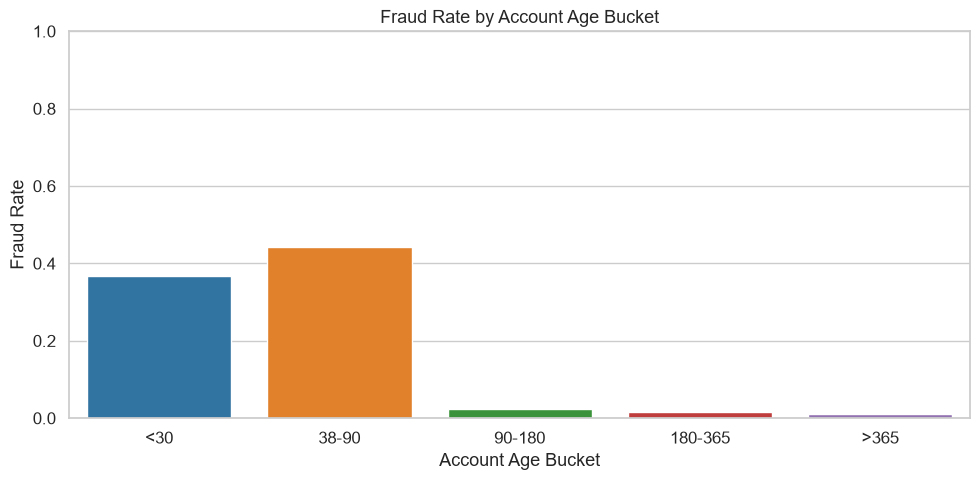

In [68]:
# Create account age buckets

customer_transaction_data['account_age_bucket'] = pd.cut(
    customer_transaction_data['account_age_days'],
    bins=[0, 30, 90, 180, 355, 2000],
    labels=['<30', '38-90', '90-180', '180-365', '>365']
 )

# Calculate Fraud rate by account age bucket
fraud_rate_by_account_age =(
    customer_transaction_data.groupby('account_age_bucket', observed=True)['is_fraud']
     .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
   data=fraud_rate_by_account_age,
   x='account_age_bucket',
   y='is_fraud',
   palette='tab10'
)

plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.ylim(0, 1)
plt.title('Fraud Rate by Account Age Bucket')

plt.tight_layout()
plt.show()


#### Observation:

Account Age and Fraud Behaviour

Account age was analysed to determine whether the age of a customer account is associated with fraudulent transaction activity.

The `account_age_days` variable was grouped into five categories:
- less than 30 days, 30–90 days, 90–180 days, 180–365 days, and more than 365 days. Fraud rates were then calculated for each group.

The analysis indicates that fraud risk varies across account-age groups. In particular, newer accounts should be examined closely because they may have limited behavioural history and may exhibit different transaction patterns from established accounts.

Transaction volume was considered alongside fraud rate to avoid over-interpreting groups with very few observations.

Comparison of the underlying `account_age_days` variable between fraudulent and legitimate transactions also provides evidence about whether fraudulent activity is concentrated among younger accounts.

The analysis identifies `account_age_days` as a potentially useful predictor. Potential derived features include `account_age_bucket`, `is_new_account`, `is_very_new_account`, and a log-transformed account age variable.

Account age will not be interpreted as evidence of fraud on its own. It will instead be evaluated alongside transaction, customer, device, geographic, and behavioural variables during feature engineering and model development.

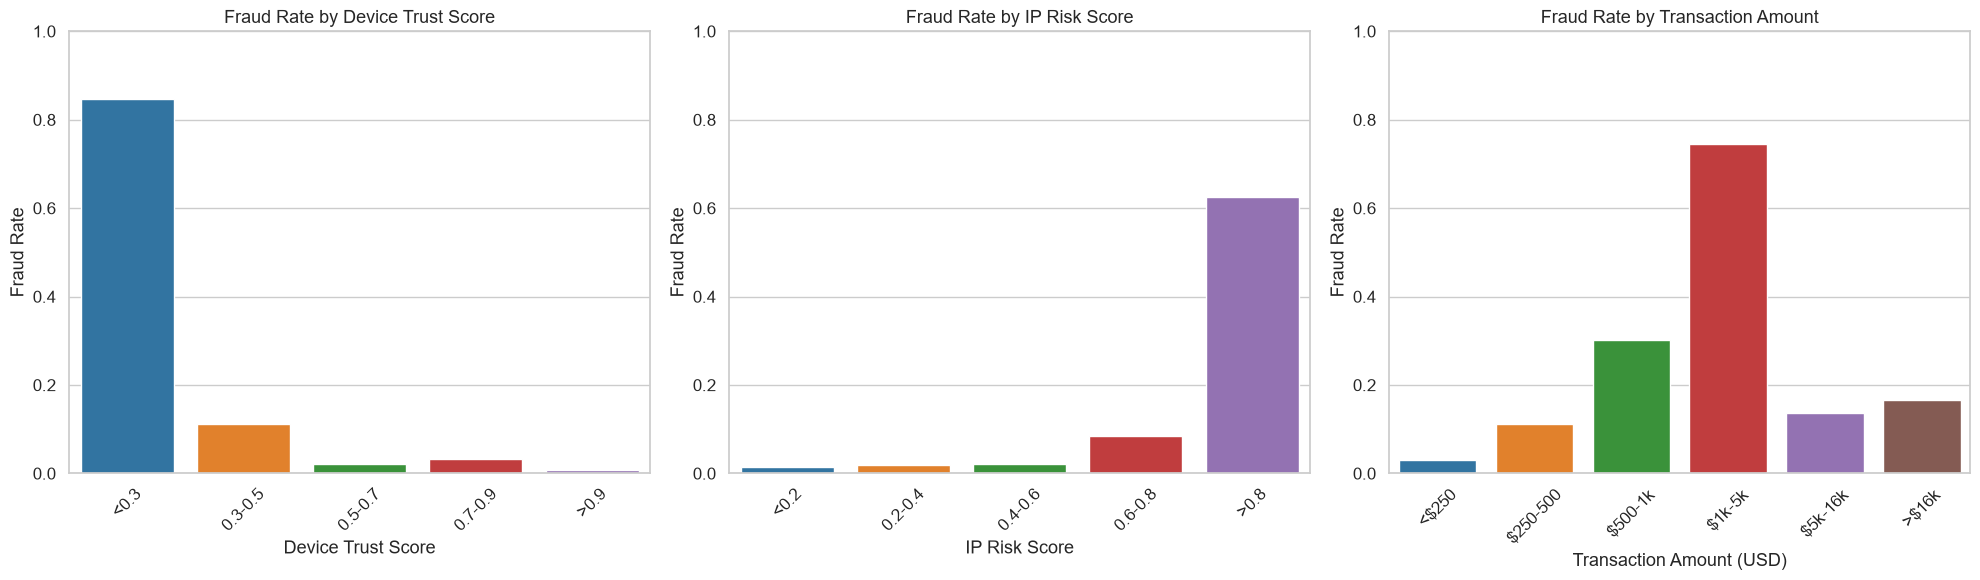

In [69]:
# Create 3 columns 

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fraud Rate by Device Trust Score

customer_transaction_data['device_trust_score_bucket'] = pd.cut( 
     customer_transaction_data['device_trust_score'], 
     bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0], 
     labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
     include_lowest=True
)

fraud_rate_by_device_trust_score = (
    customer_transaction_data.groupby(
        'device_trust_score_bucket',
        observed=True
    )['is_fraud']
    .mean()
    .reset_index()
)

sns.barplot(
    data=fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_ylim(0, 1)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].tick_params(axis= 'x', rotation=45)

# 2. Fraud Rate by IP Risk Score      

customer_transaction_data['ip_risk_score_bucket'] = pd.cut(
    customer_transaction_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.8], 
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
    )

fraud_rate_by_ip_risk_score = ( 
    customer_transaction_data.groupby(
        'ip_risk_score_bucket', 
        observed=True
    )['is_fraud']
     .mean() 
     .reset_index()
)

sns.barplot(
    data=fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette='tab10'
)

axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].tick_params(axis='x', rotation=45)

# 3. Fraud Rate by Transaction Amount

customer_transaction_data['amount_usd_bucket'] = pd.cut( 
    customer_transaction_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, 20000], 
    labels=['<$250', '$250-500', '$500-1k', '$1k-5k', '$5k-16k', '>$16k'],
    include_lowest=True
)

fraud_rate_by_amount_usd = (
    customer_transaction_data.groupby( 
        'amount_usd_bucket', 
        observed=True 
        )['is_fraud'] 
        .mean()
        .reset_index()
)

sns.barplot( 
    data=fraud_rate_by_amount_usd, 
    x='amount_usd_bucket', 
    y='is_fraud', 
    ax=axes[2],
    palette='tab10'
)

axes[2].set_xlabel('Transaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate')
axes[2].set_ylim(0, 1)
axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].tick_params(axis='x', rotation=45)

# Final Layout

plt.tight_layout()
plt.show()


In [70]:
customer_transaction_data.shape

(10780, 34)

In [71]:
customer_transaction_data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'hour', 'day_of_week',
       'is_weekend', 'month', 'account_age_bucket',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket'],
      dtype='object')

##### Exploratory Data Analysis Findings

Exploratory analysis was conducted on the cleaned FinLora transaction dataset
to identify differences between fraudulent and legitimate transactions and
to identify variables suitable for subsequent feature engineering.

The analysis confirmed that fraudulent transactions represent a minority
class within the dataset, with approximately 8.91% of transactions labelled
as fraudulent after duplicate and invalid timestamp handling. This confirms
the presence of class imbalance and supports the use of fraud-sensitive
evaluation metrics during modelling.

Fraudulent transactions were associated with substantially higher transaction
amounts than legitimate transactions. Transaction velocity was also strongly
associated with fraud, particularly where multiple transactions occurred
within short time periods.

Payment-channel analysis showed that fraud rates differed across channels,
with web transactions showing a substantially higher fraud rate than mobile
transactions.

Temporal analysis identified differences in fraud activity across hours of
the day and across months. Hour-of-day and other temporal variables should
therefore be considered during feature engineering.

Customer-level analysis indicated that fraudulent transactions were more
frequently associated with younger accounts, higher transaction velocity,
previous chargeback activity, and higher risk indicators.

Device analysis showed a strong relationship between fraud and new-device
usage. Fraudulent transactions also tended to have substantially lower
device-trust scores.

Geographic analysis identified significant differences in fraud rates across
home countries and IP countries. Transactions involving a mismatch between
customer home country and IP country showed substantially higher fraud rates.

Several combinations of suspicious behaviour were also identified. New
device usage combined with location mismatch, high IP risk combined with
low device trust, and high transaction velocity produced particularly high
fraud rates.

Potential feature-engineering variables include transaction amount
transformations, transaction velocity, account age, new-device indicators,
location mismatch, IP risk, device trust, chargeback history, payment
channel, country combinations, currency, and temporal features.

The existing `risk_score_internal` variable requires further investigation
before modelling because its extremely strong relationship with the fraud
target may indicate information leakage. Variables representing information
that was only available after the transaction must not be used as predictive
features.

##### Feature Engineering

Threshold-based features were created based on key behavioural and risk indicators identified during exploraton analysis. These include low KYC verification levels, location mismatches between the registered country and IF address, and high-risk transaction characteristics such as high transaction amounts, elevated IP risk scores, and low device trust scores. These features were identified as high-risk thresholds due to their significantly elevated frauc rates. These thresholds were converted into binary risk indicators to enhance the model's ability to detect suspicious
transactions.
Creating a threshold based features from the following risk_ signal

In [72]:
# Creating a threshold based feature from the following risk_signal

customer_transaction_data['timestamp'] = pd.to_datetime(customer_transaction_data['timestamp'])
customer_transaction_data['late_night_hours'] = ((customer_transaction_data['hour'] >= 3) & (customer_transaction_data['hour'] <=7)).astype(int)
customer_transaction_data['amount_high'] = (customer_transaction_data['amount_usd'] >= 1000).astype(int)
customer_transaction_data['high_ip_risk'] = (customer_transaction_data['ip_risk_score'] > 0.8).astype(int)
customer_transaction_data['low_device_trust'] = (customer_transaction_data['device_trust_score'] < 0.5).astype(int)
customer_transaction_data['new_account'] = ((customer_transaction_data['account_age_days'] >= 30) & (customer_transaction_data['account_age_days'] < 90)).astype(int) 
customer_transaction_data['very_new_account'] = (customer_transaction_data['account_age_days'] < 30).astype(int)
customer_transaction_data['velocity_spike'] = (customer_transaction_data['txn_velocity_1h'] >= 3).astype(int)

high_risk_signal_features = customer_transaction_data[['late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'velocity_spike']]
high_risk_signal_features.head()                                                                     

,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,velocity_spike
0,0,0,0,0,0,0
1,0,0,0,1,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [73]:
# Checking the features in our dataset
list(customer_transaction_data.columns)

['transaction_id',
 'customer_id',
 'timestamp',
 'home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'exchange_rate_src_to_dest',
 'device_id',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'ip_risk_score',
 'kyc_tier',
 'account_age_days',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'txn_velocity_1h',
 'txn_velocity_24h',
 'corridor_risk',
 'is_fraud',
 'hour',
 'day_of_week',
 'is_weekend',
 'month',
 'account_age_bucket',
 'device_trust_score_bucket',
 'ip_risk_score_bucket',
 'amount_usd_bucket',
 'late_night_hours',
 'amount_high',
 'high_ip_risk',
 'low_device_trust',
 'new_account',
 'very_new_account',
 'velocity_spike']

#### Feature Selection

In [74]:
# Dropping all temporary buckets column
customer_transaction_data = customer_transaction_data.drop(['account_age_bucket','device_trust_score_bucket','ip_risk_score_bucket','amount_usd_bucket'], axis=1)
                                                            
# Dropping all identifiers column (Ids) 
customer_transaction_data = customer_transaction_data.drop(['transaction_id', 'customer_id', 'device_id', 'ip_address'], axis=1)

# Dropping some irrelevant variables 
customer_transaction_data = customer_transaction_data.drop(['chargeback_history_count', 'month', 'exchange_rate_src_to_dest'], axis=1)

##### Defining Categorical Features

In [75]:
categorical_features = customer_transaction_data.select_dtypes(include=['object','bool']).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

##### Defining Numerical Features

In [76]:
# Defining numerical features
numerical_features = customer_transaction_data.select_dtypes(include=['int','float']).columns.drop('is_fraud')
numerical_features                                                                                                   
                                                                                                   

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [77]:
all_features = list (categorical_features) + list (numerical_features)
print(all_features)

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


In [78]:
print(f"Categorical: {len(categorical_features)}")
print(f"Numerical: {len(numerical_features)}")
print(f"Dataset: {customer_transaction_data.shape}")      

Categorical: 8
Numerical: 20
Dataset: (10780, 30)


In [79]:
customer_transaction_data.columns

Index(['timestamp', 'home_country', 'source_currency', 'dest_currency',
       'channel', 'amount_src', 'amount_usd', 'fee', 'new_device',
       'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier',
       'account_age_days', 'device_trust_score', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high',
       'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [80]:
customer_transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10780 entries, 0 to 11399
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   timestamp            10780 non-null  datetime64[ns, UTC]
 1   home_country         10756 non-null  object             
 2   source_currency      10780 non-null  object             
 3   dest_currency        10780 non-null  object             
 4   channel              10780 non-null  object             
 5   amount_src           10780 non-null  float64            
 6   amount_usd           10780 non-null  float64            
 7   fee                  10780 non-null  float64            
 8   new_device           10780 non-null  bool               
 9   ip_country           10752 non-null  object             
 10  location_mismatch    10780 non-null  bool               
 11  ip_risk_score        10780 non-null  float64            
 12  kyc_tier             10

#### Modelling

In [81]:
customer_transaction_data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,day_of_week,is_weekend,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,False,us,...,18,0,0,0,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,True,ca,...,20,0,0,0,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,False,us,...,23,0,0,0,0,0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,2.22,False,us,...,1,1,0,0,0,0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,3.61,False,us,...,9,1,0,0,0,0,0,0,0,0


##### Train_test Split

The data is split into: 80% of data used to train the model and 20% is reserved to test its performance on unseen data.

It is strongly recommended to sort the dataset chronologically before doing the train-test split. Since the dataset has a timestamp column, the order of events matters. This will prevent data leakage, help predict future transactions since model will trained on past transactions hence mimicing the real scenario.

Features like: txn_velocity_1h, -txn_velocity_24h, new_device, account_age_days, new_account depend on historical order. If data is not ordered by time, these features can become incorrect.

In [82]:
# sorting by timestamp
customer_transaction_data = customer_transaction_data.sort_values(by='timestamp')

# 80/20 train_test split 
split_index = int(len(customer_transaction_data) * 0.8) #This determines where the dataset should be split. 
train_customer_transaction_data = customer_transaction_data.iloc[:split_index] #training on future transactions
test_customer_transaction_data = customer_transaction_data.iloc[split_index:] #testing on past transactions

# prepare x and y 
x_train = train_customer_transaction_data[all_features]
y_train = train_customer_transaction_data['is_fraud'] 
x_test = test_customer_transaction_data[all_features] 
y_test = test_customer_transaction_data['is_fraud']

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


x_train: (8624, 28), y_train: (8624,)
x_test: (2156, 28), y_test: (2156,)


In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Building Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

##### Training Logistic Regression With a Balanced Class Weight

In [84]:
# Create Logistic Rrgression Model
lr_model = LogisticRegression(
    class_weight='balanced', 
    random_state=42,
    max_iter=1000
)

# Build the Complete Pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', lr_model)
    ]
)


# Train the pipeline
pipeline.fit(x_train, y_train)

# Make predictions 
y_pred_lr = pipeline.predict(x_test)
y_proba_lr = pipeline.predict_proba(x_test)[:, 1]

# Evaluation 
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.97      1848
       Fraud       0.79      0.95      0.86       308

    accuracy                           0.96      2156
   macro avg       0.89      0.95      0.92      2156
weighted avg       0.96      0.96      0.96      2156


Confusion Matrix:
[[1771   77]
 [  16  292]]

ROC_AUC Score: 0.9834


##### Confusion Matrix for Linear Regression

<Figure size 800x600 with 0 Axes>

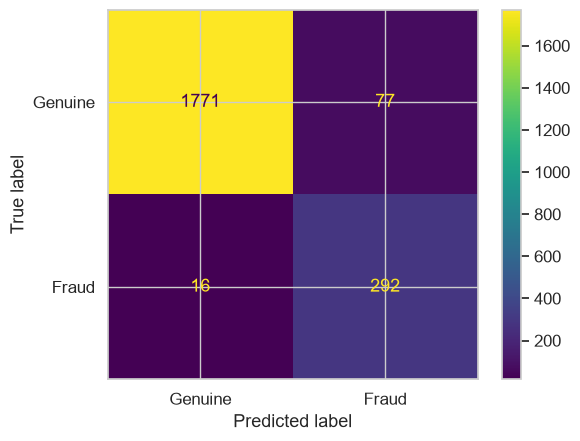

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6)) 
cm.plot()

##### Training Random forest with balanced class weight

In [86]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model 
rf_model = RandomForestClassifier(
    class_weight='balanced', 
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1 
)

# Build the complete pipeline 
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)

# Train the pipeline (using raw x_train, not processed)
pipeline_rf.fit(x_train, y_train)

# Make predictions
y_pred_rf = pipeline_rf.predict(x_test)
y_proba_rf = pipeline_rf.predict_proba(x_test)[:, 1]

# Evaluation
print("Random Forest Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.97      0.92      0.94       308

    accuracy                           0.98      2156
   macro avg       0.98      0.96      0.97      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1838   10]
 [  25  283]]

ROC_AUC Score: 0.9744


##### Confusion Matrix for Random Forest

<Figure size 800x600 with 0 Axes>

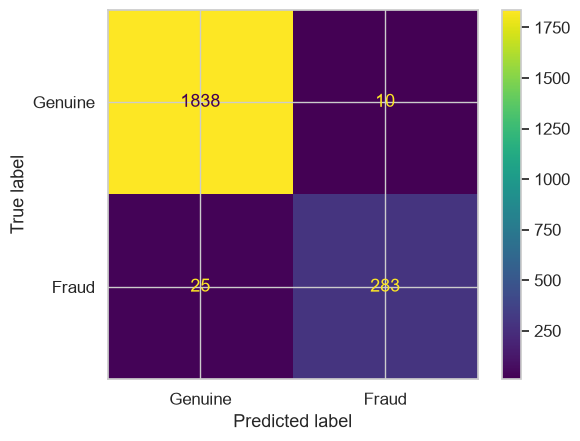

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6)) 
cm.plot()

In [88]:
from xgboost import XGBClassifier

# Calculate scale pos weight for imbalance in xgboost classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model
xgb_model = XGBClassifier(
     randon_state=42,
     n_estimators=100,
     max_depth=6,
     learning_rate=0.1,
     scale_pos_weight=scale_pos_weight,
     eval_metrix='logloss'
)

# Build the complete pipeline
pipeline_xgb = Pipeline(
    steps=[ 
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
)

# Train the pipeline (using raw x_trein, not processed)
pipeline_xgb.fit(x_train, y_train)

# Make Predictions
y_pred_xgb = pipeline_xgb.predict(x_test)
y_proba_xgb = pipeline_xgb.predict_proba(x_test)[:, 1]

# Evaluation
print("XGBBoost Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.95      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.97      0.96      0.96      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1833   15]
 [  25  283]]

ROC_AUC Score: 0.9692


##### Confusion Matrix for XGBoost

<Figure size 800x600 with 0 Axes>

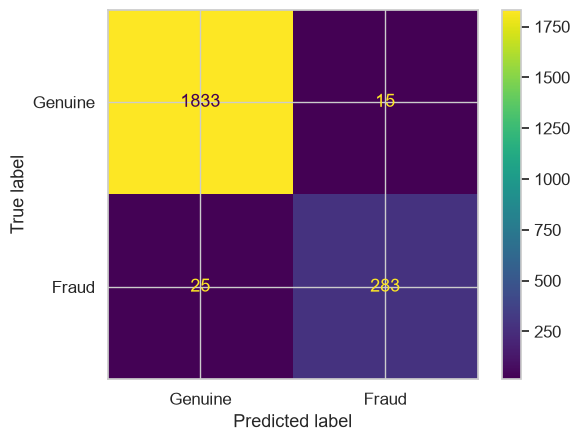

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6)) 
cm.plot()

##### SHAP ANALYSIS

SHAP is a technique used to explain machine learning predictions --- especially complex models like tree ensembles - in a way that shows how each feature contributes to a decision.

SHAP answers this question: "Why did the model say this transaction is fraud?"

It does this by assigning each feature a contribution value (positive or negative) to the prediction. SHAP is used to nterpret model predictions by quantifying the contribution of each feature to fraud risk. This enables transparency in decision-making, helped identify key fraud drivers such as transaction velocity and IP risk score, and provided actionable insights for fraud analysts and business stakeholders.

SHAP is based on Game Theory, specifically Shapley values. It fairly distributes the "credit of a prediction across features.

In [90]:
import shap
import xgboost

print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)

SHAP version: 0.52.0
XGBoost version: 2.1.4


In [91]:
import shap
import pandas as pd 
import matplotlib.pyplot as plt

# Get the preprocessor from pipeline and transfora raw X_testx
x_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(x_test)

# Get the XGBoost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifier']

# Get booster and calculate SHAP values 
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(x_test_processed)

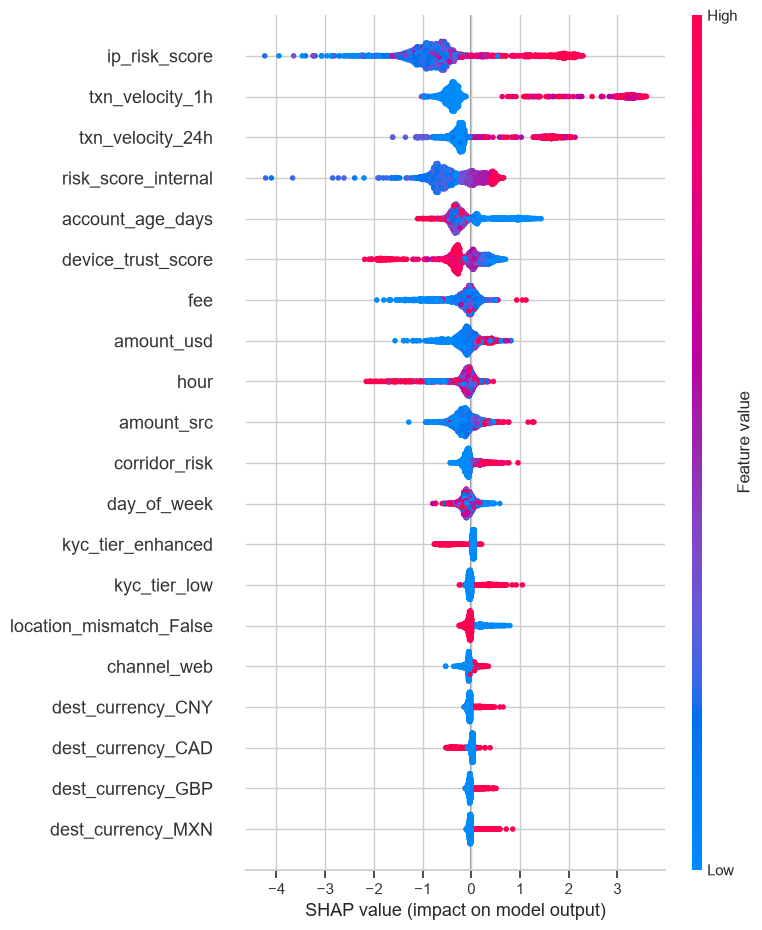

In [92]:
# Creating a clean feature name for the shap plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_test_processed_df = pd.DataFrame(
     x_test_processed,
     columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)
plt.show()

##### Observation

This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction). The Blue color represents Low feature value while the red color represents High feature value.

The Left part of the plot (negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.

SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.

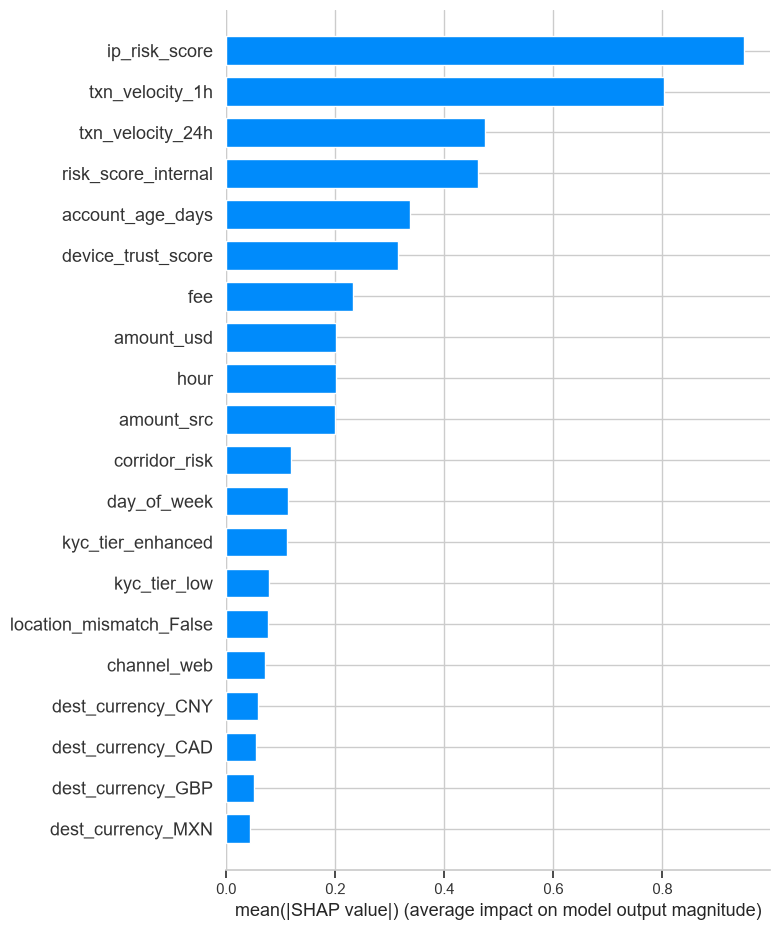

In [93]:
# Summary bar plot 
shap.summary_plot(shap_values_gb, X_test_processed_df, plot_type="bar")
plt.show()

##### Model Registering

In [96]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize DagsHub 
import dagshub
dagshub.init(repo_owner='arieanice3',
            repo_name='Fraudulent_Transaction_Detected_For_Finlora_Company',
            mlflow=True)



Initialized MLflow to track repo "arieanice3/Fraudulent_Transaction_Detected_For_Finlora_Company"

Repository arieanice3/Fraudulent_Transaction_Detected_For_Finlora_Company initialized!

In [ ]:
# Set experiment 
mlflow.set_experiment("Fraudulent_Tronsaction_Detection_Models_for_Finlora")

# Start MLFlow run and register model
with mlflow.start_run() as run:
    # Log model paraneters 
    mlflow.log_params(xgb_model.get_params())

    # Make predictions using the pipeline
    y_pred = pipeline_xgb.predict(x_test)
    y_pred_proba = pipeline_xgb.predict_proba(x_test)[:, 1]

    # Log metrics
    mlflow.log_metrics({
       'accuracy': accuracy_score(y_test, y_pred),
       'precison': precision_score(y_test, y_pred),
       'recall': recall_score(y_test, y_pred),
       'f1 score': f1_score(y_test, y_pred),
       'auc_roc': roc_auc_score(y_test, y_pred_proba)
   })

    # Log the entire pipeline (preprocessor + model) with cloudpickle serialization
    mlflow.sklearn.log_model(
         pipeline_xgb,
         "xgboost_fraud_detection_pipeline",
         registered_model_name="Fraud_Detection_XGBoost_ pipeline",
         serialization_format='cloudpickle'
      )

    print(f"Model registered successfully!")
    print(f" Run ID: {run.info.run_id}")


2026/09/06 13:34:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/06 13:34:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Fraud_Detection_XGBoost_ pipeline' already exists. Creating a new version of this model...
2026/09/06 13:35:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Fraud_Detection_XGBoost_ pipeline, version 6
Created version '6' of model 'Fraud_Detection_XGBoost_ pipeline'.


Model registered successfully!
 Run ID: 05263b1f3a7044bb913bcef1ad086246
🏃 View run enchanting-shrew-576 at: https://dagshub.com/arieanice3/Fraudulent_Transaction_Detected_For_Finlora_Company.mlflow/#/experiments/0/runs/05263b1f3a7044bb913bcef1ad086246
🧪 View experiment at: https://dagshub.com/arieanice3/Fraudulent_Transaction_Detected_For_Finlora_Company.mlflow/#/experiments/0


#### Why XGBoost for Model Registering:

- XGBoost was selected because it performed strongly on the structured FinLora transaction data, captured nonlinear fraud patterns and feature interactions, handled the imbalanced fraud class effectively, and supported explainability through feature importance and SHAP. Its MLflow compatibility also enables experiment tracking, model versioning, reproducibility, and deployment through the planned FastAPI service.

- XGBoost was not selected because it was the best model for registering since an actual evaluation was not performed with the other models (Logistic Regression, Random Forest, or LightGBM).

- XGBoost was registered as the selected candidate based on its evaluation performance against the defined fraud-detection metrics and its suitability for deployment and explainability requirements.